# Reconnaissance de sort (magique)
## 1. Explication du projet
Nous allons créer un projet machine learning pour reconnaître différents sorts et passer par toute la chaîne d'apprentissage: de l'acquisition des données brutes, leur split et leur pré-traitement, l'entraînement du modèle avec les données d'entraînement, et le test du modèle obtenu. L'analyse des métriques sera également étudié. 

## 2. Upload d'un dataset


In [1]:
!pip install pyserial

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Upload du fichier zip contenant les données brutes
import zipfile
import os

zip_path = "reconnaissance-sort-export.zip" #Création d'une variable contenant le nom du fichier zip à ouvrir
data_sort = "edge_impulse_data" #Création d'une variable contenant le nom du fichier où on veut extraire le fichier zip

#Décompression du fichier zip vers la variable sort
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(data_sort)

#Que contient le fichier zip extrait
os.listdir(data_sort)

['info.labels', 'README.txt', 'testing', 'training']

In [3]:
# Création d'un tableau pandas qui contient toutes les données

import glob
import json
import pandas as pd
import os

# Récupération de tous les fichiers JSON
files = glob.glob("edge_impulse_data/**/*.json", recursive=True)

dfs = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        d = json.load(f)

    # Certains fichiers Edge Impulse ont les données dans "payload"
    payload = d["payload"] if "payload" in d else d

    # Récupération du nom des capteurs
    colonnes = [sensor["name"] for sensor in payload["sensors"]]

    # Transformation des mesures en tableau
    df = pd.DataFrame(payload["values"], columns=colonnes)

    # Chemin du fichier source
    df["source_file"] = file

    # Label = première partie du nom du fichier
    # Exemple : Expelliarmus.6r4pg4tp.ingestion-xxx.json -> Expelliarmus
    nom_fichier = os.path.splitext(os.path.basename(file))[0]
    df["label"] = nom_fichier.split(".")[0]

    # Données protégées : elles ne pourront pas être supprimées depuis le menu
    df["origine"] = "edge_impulse"

    dfs.append(df)

# Fusion de tous les tableaux
data = pd.concat(dfs, ignore_index=True)

print("Nombre de fichiers JSON importés :", len(files))
print("Taille du dataset :", data.shape)

data.head()


Nombre de fichiers JSON importés : 300
Taille du dataset : (75000, 9)


,AxX,AxY,AxZ,GxX,GxY,GxZ,source_file,label,origine
0,9.0544,-1.4692,3.4122,2.31,1.54,1.96,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse
1,9.0927,-1.7228,3.4696,0.49,1.05,2.59,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse
2,9.1071,-1.7228,3.4839,-0.98,0.35,4.06,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse
3,9.1406,-1.9813,3.4600,1.26,-0.21,3.50,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse
4,9.1310,-2.0100,3.3404,-0.56,0.07,2.38,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus,edge_impulse


## 3. Acquisition de nouvelles données 

In [4]:
# ============================================================
# 3 - Acquisition de nouvelles données avec Seeed XIAO nRF52840
# ============================================================

# À lancer une seule fois si pyserial n'est pas installé
# !pip install pyserial

import serial
import time
import pandas as pd
from datetime import datetime

PORT = "COM10"          # À modifier selon ton ordinateur
BAUDRATE = 115200
DUREE_ACQUISITION = 5  # durée d'une acquisition en secondes

# On reprend les colonnes capteurs du dataset déjà chargé
colonnes_capteurs = [
    "AxX",
    "AxY",
    "AxZ",
    "GxX",
    "GxY",
    "GxZ"
]


def choisir_label():
    labels = sorted(data["label"].unique())

    print("\n1 - Créer un nouveau label")
    print("2 - Utiliser un label existant")

    choix = input("Choix : ")

    if choix == "1":
        label = input("Nom du nouveau label : ").strip()
        return label

    elif choix == "2":
        print("\nLabels existants :")
        for i, label in enumerate(labels):
            print(f"{i + 1} - {label}")

        choix_label = int(input("Choisir un label : ")) - 1

        if 0 <= choix_label < len(labels):
            return labels[choix_label]
        else:
            print("Choix invalide.")
            return None

    else:
        print("Choix invalide.")
        return None


def lire_fenetre_xiao(label):
    global data

    donnees = []

    print(f"\nPrépare le geste pour le label : {label}")
    input("Appuie sur Entrée pour lancer l'acquisition...")

    ser = serial.Serial(PORT, BAUDRATE, timeout=1)
    time.sleep(3)  # laisse le temps à la XIAO de redémarrer

    ser.reset_input_buffer()
    ser.reset_output_buffer()

    # Envoie la commande de départ
    ser.write(b"S")
    ser.flush()

    print("Acquisition en cours...")

    debut = time.time()

    while True:
        ligne = ser.readline().decode("utf-8", errors="ignore").strip()

        if ligne == "":
            continue

        print("Reçu :", ligne)  # ligne de debug temporaire

        if ligne == "FIN":
            break

        try:
            valeurs = [float(x) for x in ligne.split(",")]

            if len(valeurs) == len(colonnes_capteurs):
                donnees.append(valeurs)
            else:
                print("Ligne ignorée, mauvais nombre de valeurs :", ligne)

        except:
            print("Ligne ignorée :", ligne)

    ser.close()

    if len(donnees) == 0:
        print("Aucune donnée reçue.")
        return None

    df_new = pd.DataFrame(donnees, columns=colonnes_capteurs)

    nom_acquisition = f"{label}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    df_new["source_file"] = nom_acquisition
    df_new["label"] = label
    df_new["origine"] = "xiao"

    data = pd.concat([data, df_new], ignore_index=True)

    print(f"Acquisition ajoutée : {nom_acquisition}")
    print(f"Nombre de lignes ajoutées : {len(df_new)}")

    return df_new


def ajouter_une_acquisition():
    label = choisir_label()

    if label is None or label == "":
        print("Label invalide.")
        return

    df_new = lire_fenetre_xiao(label)

    if df_new is not None:
        display(df_new.head())


def faire_10_acquisitions():
    label = choisir_label()

    if label is None or label == "":
        print("Label invalide.")
        return

    for i in range(10):
        print(f"\n========== Acquisition {i + 1}/10 ==========")

        for sec in range(3, 0, -1):
            print(f"Début dans {sec}...")
            time.sleep(1)

        lire_fenetre_xiao(label)

    print(f"\n10 acquisitions terminées pour le label : {label}")


def afficher_derniere_acquisition():
    if len(data) == 0:
        print("Dataset vide.")
        return

    dernier_source = data["source_file"].iloc[-1]
    derniere = data[data["source_file"] == dernier_source]

    print("\nDernière acquisition")
    print("Label :", derniere["label"].iloc[0])
    print("Source :", dernier_source)
    print("Nombre de lignes :", len(derniere))

    display(derniere.head())


def supprimer_derniere_acquisition():
    global data

    acquisitions_xiao = data[data["origine"] == "xiao"]

    if len(acquisitions_xiao) == 0:
        print("Aucune acquisition XIAO à supprimer.")
        print("Les données Edge Impulse sont protégées.")
        return

    dernier_source = acquisitions_xiao["source_file"].iloc[-1]

    data = data[data["source_file"] != dernier_source].reset_index(drop=True)

    print("Dernière acquisition XIAO supprimée :", dernier_source)


def supprimer_dernier_label():
    global data

    acquisitions_xiao = data[data["origine"] == "xiao"]

    if len(acquisitions_xiao) == 0:
        print("Aucun label XIAO à supprimer.")
        print("Les labels Edge Impulse sont protégés.")
        return

    dernier_label = acquisitions_xiao["label"].iloc[-1]

    # Vérifie si le label existait déjà dans Edge Impulse
    label_protege = dernier_label in data[data["origine"] == "edge_impulse"]["label"].unique()

    if label_protege:
        print(f"Impossible de supprimer le label '{dernier_label}' car il existe dans Edge Impulse.")
        print("Seules les données XIAO ajoutées à ce label peuvent être supprimées.")
        return

    data = data[data["label"] != dernier_label].reset_index(drop=True)

    print("Label XIAO supprimé avec toutes ses données :", dernier_label)


def afficher_labels():
    print("\nLabels existants :")
    print(data["label"].value_counts())


def menu_acquisition():
    while True:
        print("\n===== MENU ACQUISITION =====")
        print("1 - Ajouter une acquisition")
        print("2 - Faire 10 acquisitions à la suite")
        print("3 - Afficher la dernière acquisition")
        print("4 - Supprimer la dernière acquisition")
        print("5 - Supprimer le dernier label avec ses données")
        print("6 - Afficher les labels")
        print("7 - Quitter")

        choix = input("Choix : ")

        if choix == "1":
            ajouter_une_acquisition()

        elif choix == "2":
            faire_10_acquisitions()

        elif choix == "3":
            afficher_derniere_acquisition()

        elif choix == "4":
            supprimer_derniere_acquisition()

        elif choix == "5":
            supprimer_dernier_label()

        elif choix == "6":
            afficher_labels()

        elif choix == "7":
            print("Fin du menu.")
            break

        else:
            print("Choix invalide.")



In [5]:
menu_acquisition()


===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Faire 10 acquisitions à la suite
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition
5 - Supprimer le dernier label avec ses données
6 - Afficher les labels
7 - Quitter


Choix :  7


Fin du menu.


## 4. Répartition des données en training/test

In [6]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

def split_dataset(data, test_size=0.2, random_state=42):
    """
    Sépare le dataset en ensembles d'entraînement et de test.

    Le découpage est effectué par acquisition (source_file) afin qu'une
    acquisition complète appartienne soit au jeu d'entraînement, soit au
    jeu de test. La proportion train/test est respectée pour chaque label.

    Paramètres
    ----------
    data : DataFrame
        Dataset complet.
    test_size : float
        Proportion des acquisitions à placer dans le jeu de test.
    random_state : int
        Graine aléatoire.

    Retour
    ------
    train_data, test_data
    """

    train_files = []
    test_files = []

    # Traitement indépendant pour chaque label
    for label in data["label"].unique():

        acquisitions = (
            data[data["label"] == label]["source_file"]
            .drop_duplicates()
            .tolist()
        )

        train, test = train_test_split(
            acquisitions,
            test_size=test_size,
            random_state=random_state,
            shuffle=True
        )

        train_files.extend(train)
        test_files.extend(test)

    # Construction des DataFrames
    train_data = data[data["source_file"].isin(train_files)].copy()
    test_data = data[data["source_file"].isin(test_files)].copy()

    train_data.reset_index(drop=True, inplace=True)
    test_data.reset_index(drop=True, inplace=True)

    print(f"Pourcentage de test demandé : {test_size*100:.0f}%")
    print(f"Nombre de lignes training : {len(train_data)}")
    print(f"Nombre de lignes testing : {len(test_data)}")
    print(f"Shape training : {train_data.shape}")
    print(f"Shape testing : {test_data.shape}")

    print("\nRépartition par label :")
    repartition = pd.DataFrame({
        "Training": train_data.groupby("label")["source_file"].nunique(),
        "Testing": test_data.groupby("label")["source_file"].nunique()
    }).fillna(0).astype(int)

    repartition["Total"] = repartition["Training"] + repartition["Testing"]
    repartition["% Test"] = (
        repartition["Testing"] / repartition["Total"] * 100
    ).round(1)

    display(repartition)

    return train_data, test_data

In [7]:
# Exemple : 25 % des données pour le test
train_data, test_data = split_dataset(data, test_size=0.25)

Pourcentage de test demandé : 25%
Nombre de lignes training : 56250
Nombre de lignes testing : 18750
Shape training : (56250, 9)
Shape testing : (18750, 9)

Répartition par label :


,Training,Testing,Total,% Test
label,,,,
Expelliarmus,75,25,100,25.0
Stupefy,75,25,100,25.0
Wingardium Leviosa,75,25,100,25.0


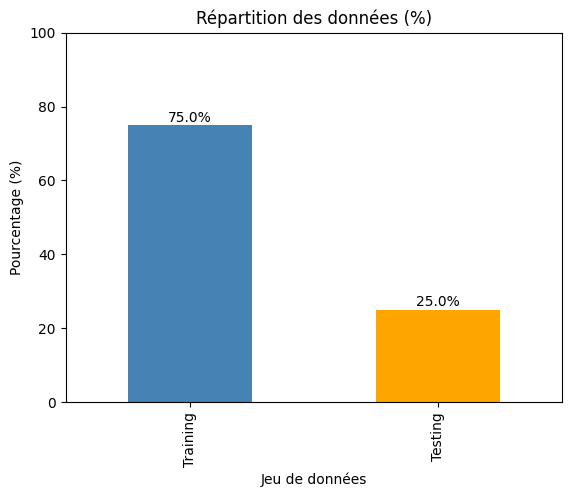

In [8]:
split_percent = pd.Series({
    "Training": len(train_data),
    "Testing": len(test_data)
})

# Conversion en pourcentages
split_percent = split_percent / split_percent.sum() * 100

ax = split_percent.plot(kind="bar", color=["steelblue", "orange"])

plt.title("Répartition des données (%)")
plt.xlabel("Jeu de données")
plt.ylabel("Pourcentage (%)")
plt.ylim(0, 100)

for i, v in enumerate(split_percent):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

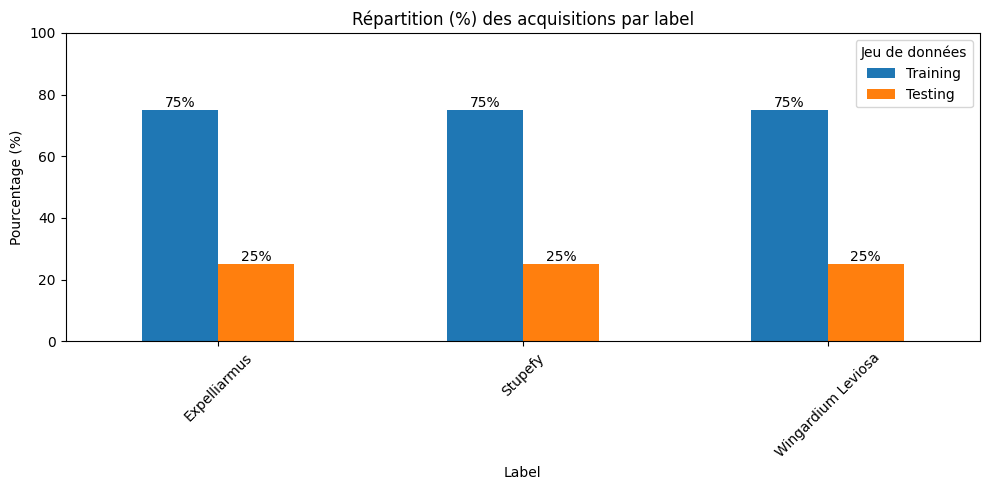

In [9]:
# Nombre d'acquisitions (source_file) par label dans chaque jeu

train_counts = (
    train_data.groupby("label")["source_file"]
    .nunique()
    .rename("Training")
)

test_counts = (
    test_data.groupby("label")["source_file"]
    .nunique()
    .rename("Testing")
)

# Fusion des résultats
label_split = pd.concat([train_counts, test_counts], axis=1).fillna(0)

# Conversion en pourcentage pour chaque label
label_split_percent = (
    label_split.div(label_split.sum(axis=1), axis=0) * 100
)

# Affichage
ax = label_split_percent.plot(kind="bar", figsize=(10, 5))

plt.title("Répartition (%) des acquisitions par label")
plt.xlabel("Label")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%")

plt.legend(title="Jeu de données")
plt.tight_layout()
plt.show()

## 5. Analyse spectrale


In [10]:
#Choix d'une fonction à analyser

def choisir_acquisition(dataset, label, numero=0):
    """
    Sélectionne une acquisition d'un label.

    Paramètres
    ----------
    dataset : train_data ou test_data
    label : nom du label
    numero : indice de l'acquisition (0 = première, 1 = deuxième, ...)
    """

    acquisitions = (
        dataset[dataset["label"] == label]["source_file"]
        .drop_duplicates()
        .tolist()
    )

    sample_file = acquisitions[numero]
    sample = dataset[dataset["source_file"] == sample_file]

    return sample


# Exemple
sample = choisir_acquisition(train_data, "Expelliarmus")

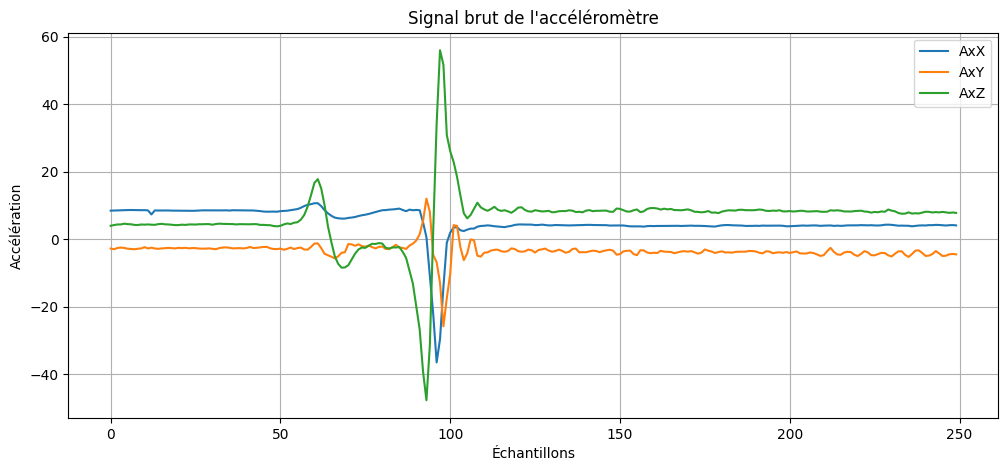

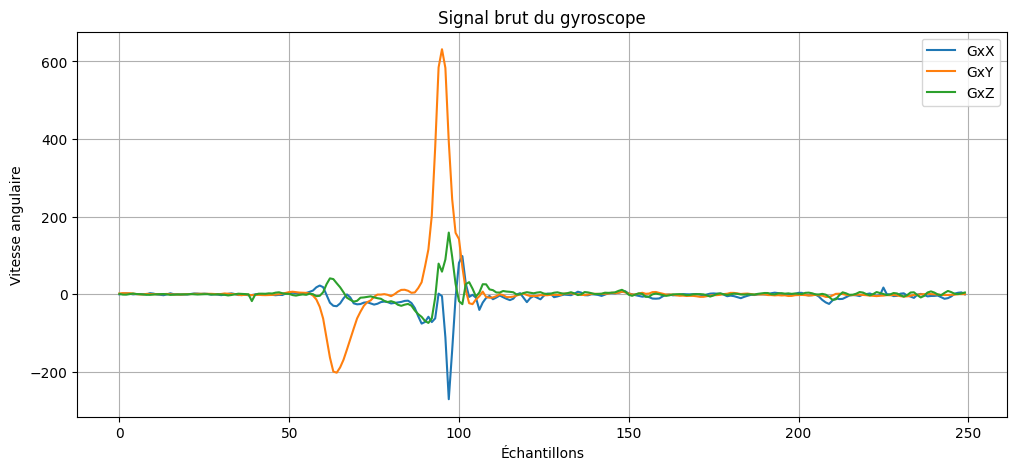

In [11]:
#Image en temporel de la donnée brute
# Image en temporel de la donnée brute (accéléromètre)

plt.figure(figsize=(12, 5))

plt.plot(sample["AxX"], label="AxX")
plt.plot(sample["AxY"], label="AxY")
plt.plot(sample["AxZ"], label="AxZ")

plt.title("Signal brut de l'accéléromètre")
plt.xlabel("Échantillons")
plt.ylabel("Accélération")
plt.legend()
plt.grid(True)

plt.show()

# Image en temporel de la donnée brute (gyroscope)

plt.figure(figsize=(12, 5))

plt.plot(sample["GxX"], label="GxX")
plt.plot(sample["GxY"], label="GxY")
plt.plot(sample["GxZ"], label="GxZ")

plt.title("Signal brut du gyroscope")
plt.xlabel("Échantillons")
plt.ylabel("Vitesse angulaire")
plt.legend()
plt.grid(True)

plt.show()

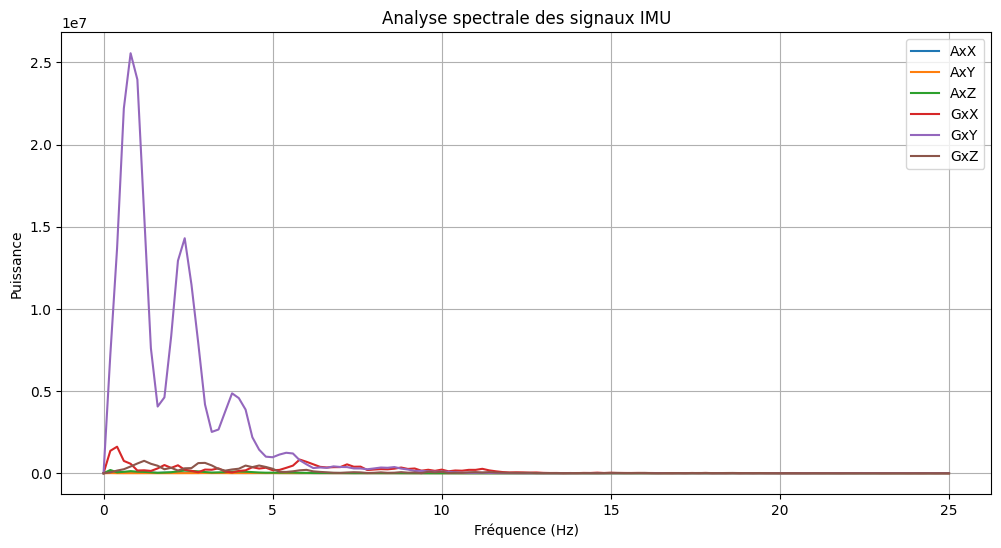

In [12]:
# Analyse spectrale (FFT)

import numpy as np
import matplotlib.pyplot as plt

# Fréquence d'échantillonnage
interval_ms = 20          # 20 ms si la XIAO échantillonne à 50 Hz (delay(20))
fs = 1000 / interval_ms

axes = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]

plt.figure(figsize=(12, 6))

# Application de la FFT sur chaque axe
for axis in axes:

    signal = sample[axis].values

    # Suppression de la composante continue
    signal = signal - np.mean(signal)

    fft_values = np.fft.rfft(signal)
    power = np.abs(fft_values) ** 2
    fft_freqs = np.fft.rfftfreq(len(signal), d=1/fs)

    plt.plot(fft_freqs, power, label=axis)

plt.title("Analyse spectrale des signaux IMU")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance")
plt.legend()
plt.grid(True)

plt.show()

## 6. Génération de features

In [13]:
from sklearn.model_selection import train_test_split
import pandas as pd

def split_train_validation(train_data, validation_size=0.2, random_state=42):
    """
    Sépare le jeu d'entraînement en un jeu d'entraînement et un jeu de validation.

    Le découpage est effectué par acquisition (source_file) afin qu'une
    acquisition complète appartienne soit au jeu d'entraînement, soit au
    jeu de validation. La proportion est respectée pour chaque label.

    Paramètres
    ----------
    train_data : DataFrame
        Jeu d'entraînement.
    validation_size : float
        Proportion des acquisitions à placer dans le jeu de validation.
    random_state : int
        Graine aléatoire.

    Retour
    ------
    train_final, validation_data
    """

    train_files = []
    validation_files = []

    # Découpage indépendant pour chaque label
    for label in train_data["label"].unique():

        acquisitions = (
            train_data[train_data["label"] == label]["source_file"]
            .drop_duplicates()
            .tolist()
        )

        train, validation = train_test_split(
            acquisitions,
            test_size=validation_size,
            random_state=random_state,
            shuffle=True
        )

        train_files.extend(train)
        validation_files.extend(validation)

    train_final = train_data[
        train_data["source_file"].isin(train_files)
    ].reset_index(drop=True)

    validation_data = train_data[
        train_data["source_file"].isin(validation_files)
    ].reset_index(drop=True)

    print(f"Pourcentage de validation demandé : {validation_size*100:.0f}%")
    print(f"Nombre de lignes entraînement : {len(train_final)}")
    print(f"Nombre de lignes validation : {len(validation_data)}")

    print("\nRépartition par label :")
    repartition = pd.DataFrame({
        "Training": train_final.groupby("label")["source_file"].nunique(),
        "Validation": validation_data.groupby("label")["source_file"].nunique()
    }).fillna(0).astype(int)

    repartition["Total"] = (
        repartition["Training"] + repartition["Validation"]
    )

    repartition["% Validation"] = (
        repartition["Validation"] / repartition["Total"] * 100
    ).round(1)

    display(repartition)

    return train_final, validation_data

# Deuxième découpage : Train / Validation
train_data, validation_data = split_train_validation(
    train_data,
    validation_size=0.2
)

Pourcentage de validation demandé : 20%
Nombre de lignes entraînement : 45000
Nombre de lignes validation : 11250

Répartition par label :


,Training,Validation,Total,% Validation
label,,,,
Expelliarmus,60,15,75,20.0
Stupefy,60,15,75,20.0
Wingardium Leviosa,60,15,75,20.0


In [14]:
import numpy as np
from scipy.stats import skew, kurtosis

# Axes du capteur
axes = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]


def generate_spectral_features(sample, axes=axes, n_fft=20):
    """
    Génère les caractéristiques statistiques et fréquentielles
    d'une acquisition.

    Paramètres
    ----------
    sample : DataFrame
        Acquisition à analyser.
    axes : list
        Liste des axes IMU.
    n_fft : int
        Nombre de coefficients FFT conservés.

    Retour
    ------
    dict
        Dictionnaire contenant les caractéristiques.
    """

    features = {}

    for axis in axes:

        signal = sample[axis].to_numpy(dtype=float)

        # Suppression de la composante continue
        signal = signal - np.mean(signal)

        # Caractéristiques statistiques
        features[f"{axis}_rms"] = np.sqrt(np.mean(signal**2))
        features[f"{axis}_skewness"] = skew(signal)
        features[f"{axis}_kurtosis"] = kurtosis(signal)

        # FFT
        fft_values = np.fft.rfft(signal)
        power = np.abs(fft_values) ** 2

        # Conservation des n_fft premiers coefficients
        power = power[:n_fft]

        for i, value in enumerate(power):
            features[f"{axis}_fft_{i}"] = value

    return features

In [15]:
# 2. Fonction de génération des features
def construire_features(dataset):
    feature_rows = []

    for source_file, sample in dataset.groupby("source_file"):
        features = generate_spectral_features(sample, axes, n_fft=20)

        features["source_file"] = source_file
        features["label"] = sample["label"].iloc[0]

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)

In [16]:
# 3. Génération des features pour les trois jeux
features_train = construire_features(train_data)
features_validation = construire_features(validation_data)
features_test = construire_features(test_data)

display(features_train.head())
display(features_validation.head())
display(features_test.head())

,AxX_rms,AxX_skewness,AxX_kurtosis,AxX_fft_0,AxX_fft_1,AxX_fft_2,AxX_fft_3,AxX_fft_4,AxX_fft_5,AxX_fft_6,...,GxZ_fft_12,GxZ_fft_13,GxZ_fft_14,GxZ_fft_15,GxZ_fft_16,GxZ_fft_17,GxZ_fft_18,GxZ_fft_19,source_file,label
0,4.441311,-3.246301,19.286863,7.576220e-27,166605.441121,28996.334523,18556.984213,25882.394748,8874.120558,25592.463296,...,2.468161e+04,40771.833790,138439.102409,152677.035565,8.587244e+04,3.569708e+04,2.263073e+04,1.365703e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
1,3.433160,-4.606190,31.055103,9.545217e-29,67063.721952,15054.413011,6625.346688,17742.853427,9277.737525,7434.328316,...,9.764041e+05,582563.702424,232987.733111,87492.057438,1.015123e+05,1.962421e+05,3.613438e+05,4.736041e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
2,5.504860,-5.510381,38.338418,1.135960e-26,187107.281942,18094.297519,65700.584885,27198.309786,52011.069102,49253.320860,...,1.032476e+06,893023.583274,882043.561124,617168.632154,2.615958e+05,6.751109e+05,6.271902e+05,7.325014e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
3,4.587089,-5.704205,39.499838,1.727921e-26,21502.571054,33091.960407,44167.893827,38137.839988,23838.960382,18944.098992,...,1.564331e+06,571124.083050,952168.349335,789683.119022,1.135880e+06,1.337109e+06,1.549239e+06,1.232745e+06,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
4,4.467757,-4.435736,32.104818,5.048710e-27,67853.401994,72858.757595,33088.623762,8639.918830,18575.364558,26128.834206,...,6.999767e+04,61891.082777,62310.391491,129700.604598,2.814028e+05,2.715900e+05,2.794846e+05,1.481434e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus


,AxX_rms,AxX_skewness,AxX_kurtosis,AxX_fft_0,AxX_fft_1,AxX_fft_2,AxX_fft_3,AxX_fft_4,AxX_fft_5,AxX_fft_6,...,GxZ_fft_12,GxZ_fft_13,GxZ_fft_14,GxZ_fft_15,GxZ_fft_16,GxZ_fft_17,GxZ_fft_18,GxZ_fft_19,source_file,label
0,4.735731,-5.295913,38.063668,5.048710e-29,98774.716645,71903.428488,15474.580443,35378.320186,25097.028462,14782.746986,...,2.994033e+05,3.115180e+05,6.163223e+05,6.292913e+05,4.742852e+05,2.604518e+05,1.584349e+05,2.290019e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
1,6.116574,-6.203141,46.343625,8.077936e-28,200401.360795,27522.484385,80711.204845,36824.203765,47331.573952,50963.261165,...,1.222474e+06,1.618458e+06,2.478769e+06,3.475497e+06,3.961001e+06,3.307369e+06,2.060225e+06,1.400800e+06,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
2,5.412825,-5.840789,42.840007,1.727921e-26,213894.245290,30526.848996,62234.906980,47685.297744,16675.259367,30245.048386,...,1.285203e+06,6.912885e+05,2.033646e+06,3.095936e+06,3.805794e+06,3.764316e+06,2.058104e+06,1.603090e+06,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
3,4.118658,-4.489786,27.898924,0.000000e+00,97265.941208,64520.896172,11992.207059,29763.671523,14287.911935,17930.800818,...,2.395782e+06,1.715413e+06,1.349973e+06,9.197815e+05,9.920106e+05,7.471110e+05,7.055603e+05,8.399734e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
4,4.139085,-5.556197,41.622220,1.524158e-26,114352.566241,12228.718961,38566.340770,9990.588060,24325.426912,15375.682404,...,1.842482e+06,1.525514e+06,1.512748e+06,8.502112e+05,6.852844e+05,6.700935e+05,5.889950e+05,6.705839e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus


,AxX_rms,AxX_skewness,AxX_kurtosis,AxX_fft_0,AxX_fft_1,AxX_fft_2,AxX_fft_3,AxX_fft_4,AxX_fft_5,AxX_fft_6,...,GxZ_fft_12,GxZ_fft_13,GxZ_fft_14,GxZ_fft_15,GxZ_fft_16,GxZ_fft_17,GxZ_fft_18,GxZ_fft_19,source_file,label
0,7.339634,-5.817563,39.343049,1.502307e-26,234831.285645,156045.217846,60108.979887,84637.969346,31417.362138,72000.593630,...,1.054360e+06,5.568718e+05,1.353223e+05,9.216190e+04,3.610084e+05,7.460300e+05,9.698476e+05,7.091755e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
1,3.528244,-4.716028,31.939659,5.009582e-26,61152.453882,5434.084238,24671.026827,14068.878799,31164.208143,19373.075848,...,1.040271e+06,1.598169e+06,1.810129e+06,1.643878e+06,8.612769e+05,3.672753e+05,5.731764e+05,9.473573e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
2,4.494337,-6.215725,49.161786,3.347610e-26,84108.848738,65763.249468,12250.393697,24372.422176,4511.404801,20855.410480,...,3.974058e+06,3.570636e+06,2.221355e+06,1.090313e+06,8.192954e+05,9.905236e+05,2.289853e+06,3.138939e+06,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
3,4.602513,-4.660983,26.827793,8.486881e-26,173057.521307,91098.299724,29360.466616,21752.547498,31167.048582,28941.403941,...,1.802626e+06,1.729550e+06,1.614429e+06,1.658366e+06,1.443084e+06,1.571590e+06,1.753327e+06,1.553633e+06,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus
4,3.066389,-4.076730,25.614271,1.635782e-26,87133.063408,7117.458798,16812.511286,12992.307447,5232.864761,15280.655047,...,8.426227e+04,2.030600e+05,2.395520e+05,1.923509e+05,1.170168e+05,8.833436e+04,1.134087e+05,1.721390e+05,edge_impulse_data\testing\Expelliarmus.json.6s...,Expelliarmus


In [20]:
# 4. Création de X et y
X_train = features_train.drop(columns=["source_file", "label"])
y_train = features_train["label"]

X_validation = features_validation.drop(columns=["source_file", "label"])
y_validation = features_validation["label"]

X_test = features_test.drop(columns=["source_file", "label"])
y_test = features_test["label"]

## 7. Classification sur données d'entraînement

In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

In [22]:
#Codage des labels

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_validation_encoded = label_encoder.transform(y_validation)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['Expelliarmus' 'Stupefy' 'Wingardium Leviosa']


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

In [24]:
num_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

model = Sequential([
    Dense(64, activation="relu", input_shape=(num_features,)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_data=(X_validation_scaled, y_validation_encoded),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5167 - loss: 1.1882 - val_accuracy: 0.6889 - val_loss: 0.5435
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7278 - loss: 0.5523 - val_accuracy: 0.9333 - val_loss: 0.2996
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9333 - loss: 0.2921 - val_accuracy: 1.0000 - val_loss: 0.1602
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9556 - loss: 0.2011 - val_accuracy: 1.0000 - val_loss: 0.0745
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9833 - loss: 0.1175 - val_accuracy: 1.0000 - val_loss: 0.0333
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9833 - loss: 0.0850 - val_accuracy: 1.0000 - val_loss: 0.0181
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0486 - val_accuracy: 1.0000 - val_loss: 0.0115
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0344 - val_accuracy: 1.0000 - val_loss

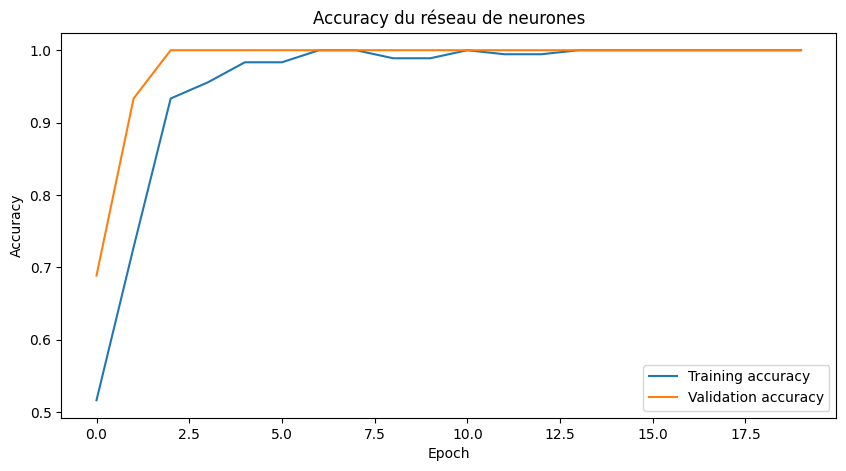

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Accuracy du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

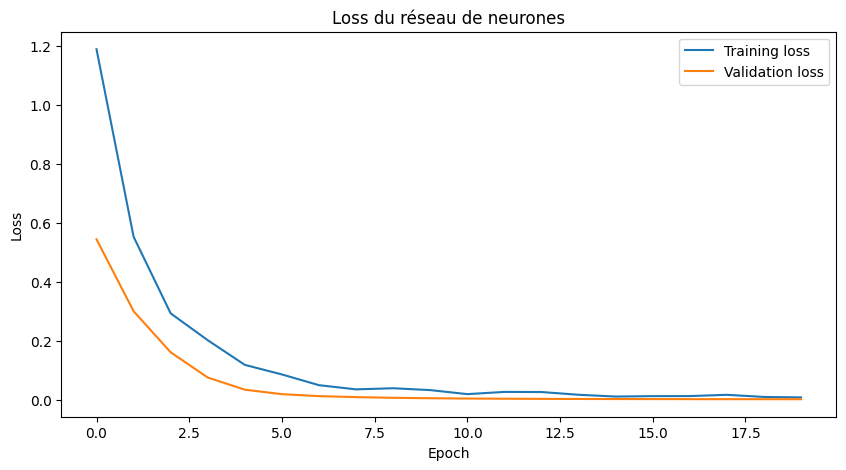

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Loss du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [29]:
#Métriques

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import numpy as np

# Prédictions sur le jeu de validation
y_validation_proba = model.predict(X_validation_scaled)
y_validation_pred = np.argmax(y_validation_proba, axis=1)

# Calcul des métriques
metrics = pd.DataFrame({
    "Metric": [
        "Area under ROC Curve",
        "Weighted average Precision",
        "Weighted average Recall",
        "Weighted average F1 score"
    ],
    "Value": [
        roc_auc_score(
            y_validation_encoded,
            y_validation_proba,
            multi_class="ovr",
            average="weighted"
        ),
        precision_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

metrics["Value"] = metrics["Value"].map(lambda x: f"{x:.2f}")

display(metrics)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


,Metric,Value
0,Area under ROC Curve,1.00
1,Weighted average Precision,1.00
2,Weighted average Recall,1.00
3,Weighted average F1 score,1.00


In [30]:
#Matrice de confusion

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def afficher_matrice_confusion(y_true, y_pred, labels):
    """
    Affiche une matrice de confusion normalisée en pourcentage.

    Paramètres
    ----------
    y_true : array
        Labels réels (encodés).
    y_pred : array
        Labels prédits (encodés).
    labels : list
        Liste des noms des classes.
    """

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)

    # Normalisation par ligne (classe réelle)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        vmin=0,
        vmax=100,
        cbar_kws={"label": "Pourcentage (%)"}
    )

    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title("Matrice de confusion (%)")

    plt.tight_layout()
    plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


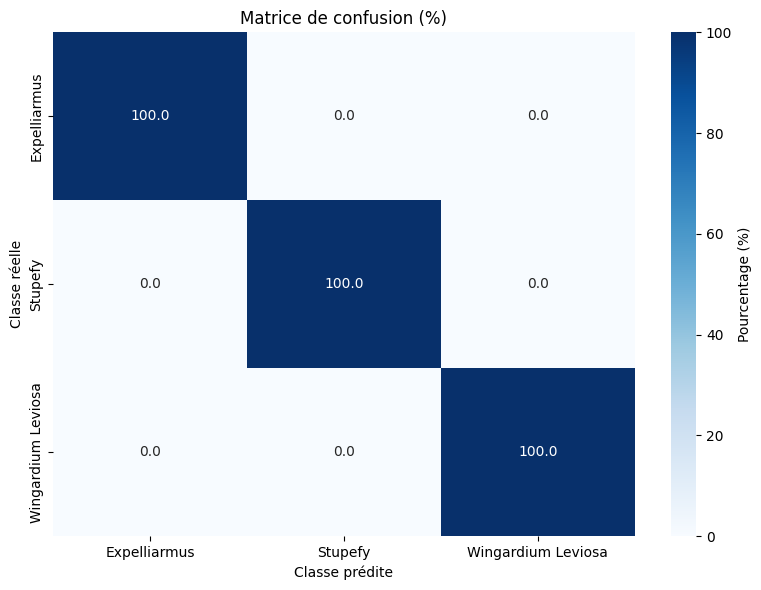

In [31]:
y_validation_proba = model.predict(X_validation_scaled)
y_validation_pred = np.argmax(y_validation_proba, axis=1)

afficher_matrice_confusion(
    y_validation_encoded,
    y_validation_pred,
    label_encoder.classes_
)

## 8. Test du modèle

In [32]:
# Données de test

X_test = features_test.drop(
    columns=["source_file", "label"]
)

y_test = features_test["label"]

In [33]:
# Encodage des labels
y_test_encoded = label_encoder.transform(y_test)

# Normalisation des caractéristiques
X_test_scaled = scaler.transform(X_test)

In [34]:
# Prédictions sur le jeu de test
y_test_proba = model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_proba, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [35]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# Calcul des métriques
test_metrics = pd.DataFrame({
    "Metric": [
        "Area under ROC Curve",
        "Weighted average Precision",
        "Weighted average Recall",
        "Weighted average F1 score"
    ],
    "Value": [
        roc_auc_score(
            y_test_encoded,
            y_test_proba,
            multi_class="ovr",
            average="weighted"
        ),
        precision_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

test_metrics["Value"] = test_metrics["Value"].map(lambda x: f"{x:.2f}")

display(test_metrics.style.hide(axis="index"))

Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


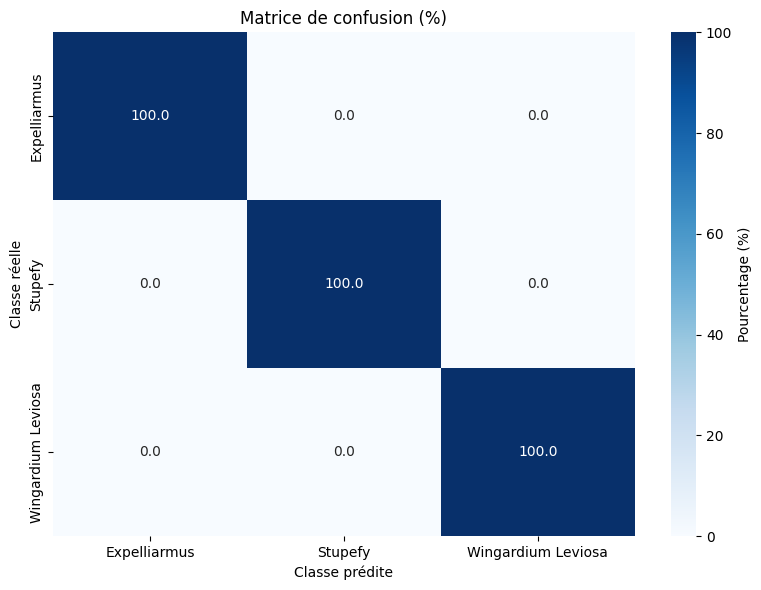

In [36]:
#Matrice de confusion

afficher_matrice_confusion(
    y_test_encoded,
    y_test_pred,
    label_encoder.classes_
)

## 9. Re-entraînement du modèle (facultatif)

In [37]:
def reentrainer_modele(
    train_data,
    validation_data,
    test_data,
    axes=["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"],
    n_fft=20,
    epochs=20,
    batch_size=16
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    from scipy.stats import skew, kurtosis
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.metrics import (
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        confusion_matrix
    )

    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    def generate_spectral_features(sample):
        features = {}

        for axis in axes:
            signal = sample[axis].to_numpy(dtype=float)
            signal = signal - np.mean(signal)

            features[f"{axis}_rms"] = np.sqrt(np.mean(signal ** 2))
            features[f"{axis}_skewness"] = skew(signal)
            features[f"{axis}_kurtosis"] = kurtosis(signal)

            fft_values = np.fft.rfft(signal)
            power = np.abs(fft_values) ** 2
            power = power[:n_fft]

            for i, value in enumerate(power):
                features[f"{axis}_fft_{i}"] = value

        return features

    def construire_features(dataset):
        feature_rows = []

        for source_file, sample in dataset.groupby("source_file"):
            features = generate_spectral_features(sample)

            features["source_file"] = source_file
            features["label"] = sample["label"].iloc[0]

            feature_rows.append(features)

        return pd.DataFrame(feature_rows)

    def afficher_metriques(y_true, y_pred, y_proba, titre):
        metrics = pd.DataFrame({
            "Metric": [
                "Area under ROC Curve",
                "Weighted average Precision",
                "Weighted average Recall",
                "Weighted average F1 score"
            ],
            "Value": [
                roc_auc_score(
                    y_true,
                    y_proba,
                    multi_class="ovr",
                    average="weighted"
                ),
                precision_score(y_true, y_pred, average="weighted", zero_division=0),
                recall_score(y_true, y_pred, average="weighted", zero_division=0),
                f1_score(y_true, y_pred, average="weighted", zero_division=0)
            ]
        })

        metrics["Value"] = metrics["Value"].map(lambda x: f"{x:.2f}")

        print(titre)
        display(metrics.style.hide(axis="index"))

    def afficher_matrice_confusion(y_true, y_pred, labels, titre):
        cm = confusion_matrix(y_true, y_pred)
        cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            cm_percent,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            vmin=0,
            vmax=100,
            cbar_kws={"label": "Pourcentage (%)"}
        )

        plt.title(titre)
        plt.xlabel("Classe prédite")
        plt.ylabel("Classe réelle")
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 1. Génération des features
    # --------------------------------------------------------

    features_train = construire_features(train_data)
    features_validation = construire_features(validation_data)
    features_test = construire_features(test_data)

    print("Features train :", features_train.shape)
    print("Features validation :", features_validation.shape)
    print("Features test :", features_test.shape)

    # --------------------------------------------------------
    # 2. Préparation des données
    # --------------------------------------------------------

    X_train = features_train.drop(columns=["source_file", "label"])
    y_train = features_train["label"]

    X_validation = features_validation.drop(columns=["source_file", "label"])
    y_validation = features_validation["label"]

    X_test = features_test.drop(columns=["source_file", "label"])
    y_test = features_test["label"]

    label_encoder = LabelEncoder()

    y_train_encoded = label_encoder.fit_transform(y_train)
    y_validation_encoded = label_encoder.transform(y_validation)
    y_test_encoded = label_encoder.transform(y_test)

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_validation_scaled = scaler.transform(X_validation)
    X_test_scaled = scaler.transform(X_test)

    print("Labels :", label_encoder.classes_)

    # --------------------------------------------------------
    # 3. Création du modèle
    # --------------------------------------------------------

    model = Sequential([
        Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(len(label_encoder.classes_), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # --------------------------------------------------------
    # 4. Entraînement
    # --------------------------------------------------------

    history = model.fit(
        X_train_scaled,
        y_train_encoded,
        validation_data=(X_validation_scaled, y_validation_encoded),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop]
    )

    # --------------------------------------------------------
    # 5. Courbes d'entraînement
    # --------------------------------------------------------

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title("Évolution de l'accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title("Évolution de la loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # 6. Évaluation validation
    # --------------------------------------------------------

    y_validation_proba = model.predict(X_validation_scaled)
    y_validation_pred = np.argmax(y_validation_proba, axis=1)

    afficher_metriques(
        y_validation_encoded,
        y_validation_pred,
        y_validation_proba,
        "Métriques - Validation"
    )

    afficher_matrice_confusion(
        y_validation_encoded,
        y_validation_pred,
        label_encoder.classes_,
        "Matrice de confusion - Validation (%)"
    )

    # --------------------------------------------------------
    # 7. Évaluation test
    # --------------------------------------------------------

    y_test_proba = model.predict(X_test_scaled)
    y_test_pred = np.argmax(y_test_proba, axis=1)

    afficher_metriques(
        y_test_encoded,
        y_test_pred,
        y_test_proba,
        "Métriques - Test"
    )

    afficher_matrice_confusion(
        y_test_encoded,
        y_test_pred,
        label_encoder.classes_,
        "Matrice de confusion - Test (%)"
    )

    return {
        "model": model,
        "history": history,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "features_train": features_train,
        "features_validation": features_validation,
        "features_test": features_test,
        "X_train_scaled": X_train_scaled,
        "X_validation_scaled": X_validation_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train_encoded": y_train_encoded,
        "y_validation_encoded": y_validation_encoded,
        "y_test_encoded": y_test_encoded
    }

Features train : (180, 140)
Features validation : (45, 140)
Features test : (75, 140)
Labels : ['Expelliarmus' 'Stupefy' 'Wingardium Leviosa']


C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4889 - loss: 1.1217 - val_accuracy: 0.6222 - val_loss: 0.8288
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6222 - loss: 0.7685 - val_accuracy: 0.9111 - val_loss: 0.5177
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8278 - loss: 0.5012 - val_accuracy: 0.9778 - val_loss: 0.3129
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9333 - loss: 0.3217 - val_accuracy: 1.0000 - val_loss: 0.1734
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9444 - loss: 0.2179 - val_accuracy: 1.0000 - val_loss: 0.0979
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9556 - loss: 0.1831 - val_accuracy: 1.0000 - val_loss: 0.0606
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9778 - loss: 0.1213 - val_accuracy: 1.0000 - val_loss: 0.0401
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9889 - loss: 0.1001 - val_accuracy: 1.0000 - val_loss

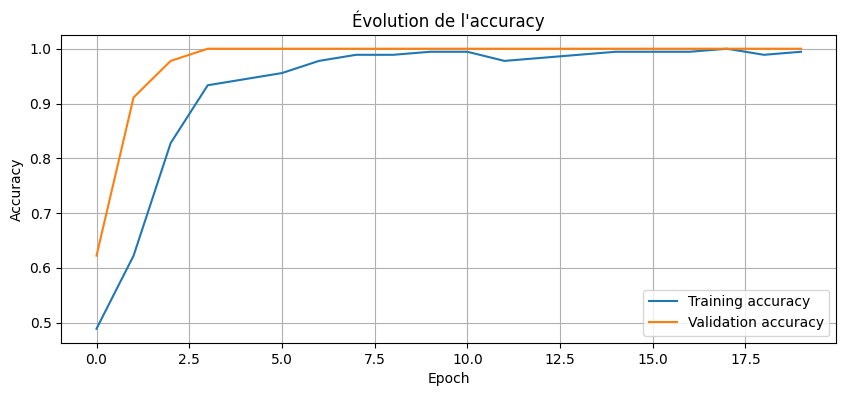

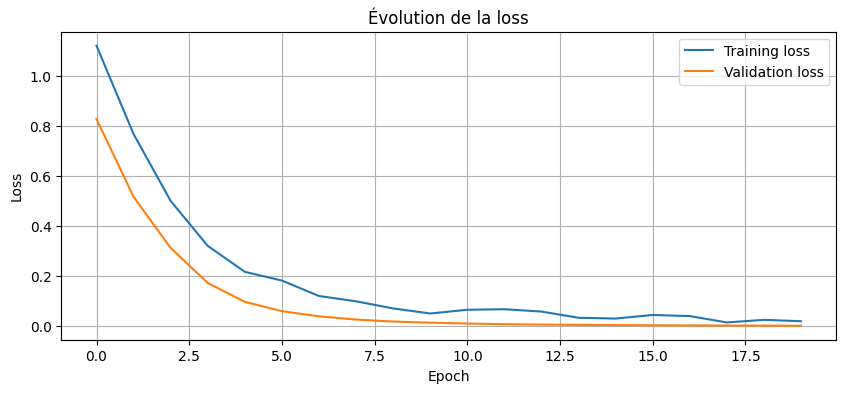

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Métriques - Validation


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


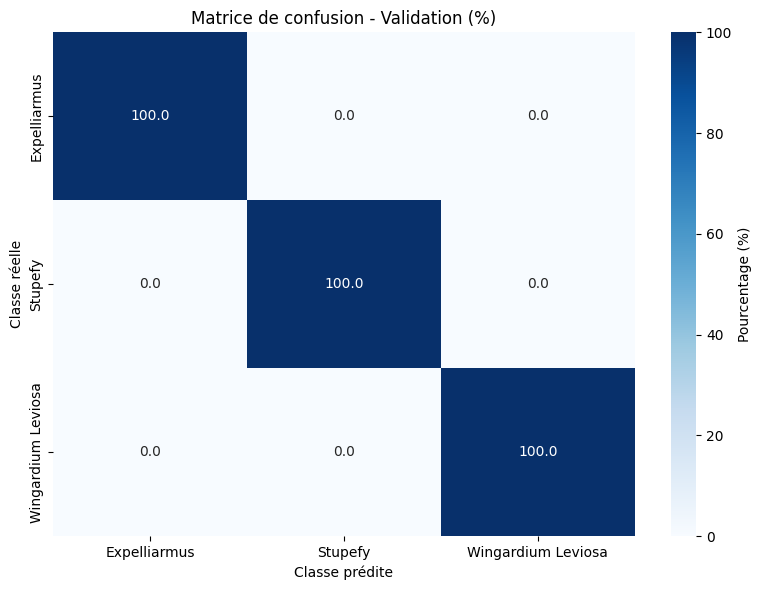

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Métriques - Test


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


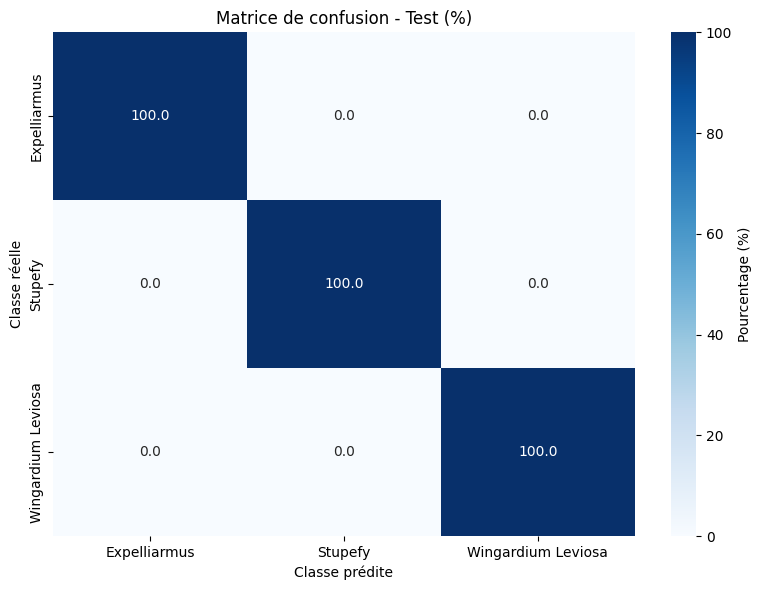

In [38]:
resultats = reentrainer_modele(
    train_data,
    validation_data,
    test_data,
    n_fft=20,
    epochs=20,
    batch_size=16
)

model = resultats["model"]
scaler = resultats["scaler"]
label_encoder = resultats["label_encoder"]

## 10. Déploiement du modèle sur la carte Seeed Xiao NRF52840 sense

In [39]:
# ============================================================
# Déploiement TFLite pour Seeed XIAO nRF52840 Sense
# Génération automatique de modele_sort.h et scaler_params.h
# ============================================================

import tensorflow as tf
import json
import os

# Récupération des éléments du modèle entraîné
model = resultats["model"]
scaler = resultats["scaler"]
label_encoder = resultats["label_encoder"]

labels = list(label_encoder.classes_)

# ------------------------------------------------------------
# 1. Conversion du modèle Keras en TensorFlow Lite
# ------------------------------------------------------------

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("modele_sort.tflite", "wb") as f:
    f.write(tflite_model)

print("Modèle TFLite généré : modele_sort.tflite")
print("Taille du modèle :", len(tflite_model), "octets")


# ------------------------------------------------------------
# 2. Génération du fichier modele_sort.h
# ------------------------------------------------------------

with open("modele_sort.h", "w") as f:
    f.write("#ifndef MODELE_SORT_H\n")
    f.write("#define MODELE_SORT_H\n\n")

    f.write("const unsigned char modele_sort[] = {\n")

    for i, byte in enumerate(tflite_model):
        if i % 12 == 0:
            f.write("  ")
        f.write(f"0x{byte:02x}, ")
        if i % 12 == 11:
            f.write("\n")

    f.write("\n};\n\n")
    f.write(f"const unsigned int modele_sort_len = {len(tflite_model)};\n\n")
    f.write("#endif\n")

print("Fichier généré : modele_sort.h")


# ------------------------------------------------------------
# 3. Génération du fichier scaler_params.h
# ------------------------------------------------------------

mean = scaler.mean_
scale = scaler.scale_

with open("scaler_params.h", "w") as f:
    f.write("#ifndef SCALER_PARAMS_H\n")
    f.write("#define SCALER_PARAMS_H\n\n")

    f.write(f"#define N_FEATURES {len(mean)}\n")
    f.write(f"#define N_CLASSES {len(labels)}\n\n")

    f.write("const float scaler_mean[N_FEATURES] = {\n")
    f.write(", ".join([f"{x:.8f}f" for x in mean]))
    f.write("\n};\n\n")

    f.write("const float scaler_scale[N_FEATURES] = {\n")
    f.write(", ".join([f"{x:.8f}f" for x in scale]))
    f.write("\n};\n\n")

    f.write("const char* labels[N_CLASSES] = {\n")
    f.write(", ".join([f'"{label}"' for label in labels]))
    f.write("\n};\n\n")

    f.write("#endif\n")

print("Fichier généré : scaler_params.h")


INFO:tensorflow:Assets written to: C:\Users\BASSAN~1\AppData\Local\Temp\tmpztfh5op1\assets


INFO:tensorflow:Assets written to: C:\Users\BASSAN~1\AppData\Local\Temp\tmpztfh5op1\assets


Saved artifact at 'C:\Users\BASSAN~1\AppData\Local\Temp\tmpztfh5op1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 138), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2680912596624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2680912598736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2680912599888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2680912599120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2680912600080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2680912595856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modèle TFLite généré : modele_sort.tflite
Taille du modèle : 9568 octets
Fichier généré : modele_sort.h
Fichier généré : scaler_params.h


In [40]:
!pip install pyserial

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
# ============================================================
# Déploiement complet XIAO + FFT + Serial Monitor depuis Jupyter
# ============================================================

import os, time, subprocess, serial, shutil, sys

PORT = "COM9"
BAUDRATE = 115200

SKETCH_NAME = "deploiement_xiao_fft"
SKETCH_DIR = r"C:\temp\deploiement_xiao_fft"

os.makedirs(SKETCH_DIR, exist_ok=True)

ino_path = os.path.join(SKETCH_DIR, SKETCH_NAME + ".ino")

FQBN = "Seeeduino:nrf52:xiaonRF52840Sense"
ARDUINO_CLI = r"U:\Stage IA\arduino-cli.exe"

arduino_code = r'''
#include <Chirale_TensorFlowLite.h>
#include "tensorflow/lite/micro/all_ops_resolver.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"

#include "LSM6DS3.h"
#include "Wire.h"
#include "modele_sort.h"
#include "scaler_params.h"

LSM6DS3 imu(I2C_MODE, 0x6A);

#define SAMPLE_RATE_HZ 50
#define WINDOW_SECONDS 2
#define N_SAMPLES 100
#define N_AXES 6
#define N_FFT 20

float buffer_data[N_SAMPLES][N_AXES];
float features[N_FEATURES];

constexpr int tensor_arena_size = 50 * 1024;
uint8_t tensor_arena[tensor_arena_size];

const tflite::Model* tflite_model;
tflite::MicroInterpreter* interpreter;
TfLiteTensor* input;
TfLiteTensor* output;
tflite::AllOpsResolver resolver;

void setup() {
  Serial.begin(115200);
  while (!Serial);

  pinMode(LED_BUILTIN, OUTPUT);
  digitalWrite(LED_BUILTIN, HIGH);

  if (imu.begin() != 0) {
    Serial.println("Erreur IMU");
    while (1);
  }

  tflite_model = tflite::GetModel(modele_sort);

  static tflite::MicroInterpreter static_interpreter(
    tflite_model,
    resolver,
    tensor_arena,
    tensor_arena_size
  );

  interpreter = &static_interpreter;

  if (interpreter->AllocateTensors() != kTfLiteOk) {
    Serial.println("Erreur allocation tenseurs");
    while (1);
  }

  input = interpreter->input(0);
  output = interpreter->output(0);

  Serial.println("XIAO prête.");
}

void loop() {
  Serial.println("Prépare le geste...");
  delay(1000);

  digitalWrite(LED_BUILTIN, LOW);
  enregistrer_fenetre();
  digitalWrite(LED_BUILTIN, HIGH);

  calculer_features();
  normaliser_features();

  for (int i = 0; i < N_FEATURES; i++) {
    input->data.f[i] = features[i];
  }

  if (interpreter->Invoke() != kTfLiteOk) {
    Serial.println("Erreur inference");
    return;
  }

  afficher_prediction();
  delay(2000);
}

void enregistrer_fenetre() {
  for (int i = 0; i < N_SAMPLES; i++) {
    buffer_data[i][0] = imu.readFloatAccelX();
    buffer_data[i][1] = imu.readFloatAccelY();
    buffer_data[i][2] = imu.readFloatAccelZ();
    buffer_data[i][3] = imu.readFloatGyroX();
    buffer_data[i][4] = imu.readFloatGyroY();
    buffer_data[i][5] = imu.readFloatGyroZ();

    delay(1000 / SAMPLE_RATE_HZ);
  }
}

float moyenne_axe(int axe) {
  float somme = 0;
  for (int i = 0; i < N_SAMPLES; i++) somme += buffer_data[i][axe];
  return somme / N_SAMPLES;
}

float rms_axe(int axe, float mean) {
  float somme = 0;
  for (int i = 0; i < N_SAMPLES; i++) {
    float x = buffer_data[i][axe] - mean;
    somme += x * x;
  }
  return sqrt(somme / N_SAMPLES);
}

float skewness_axe(int axe, float mean) {
  float m2 = 0;
  float m3 = 0;

  for (int i = 0; i < N_SAMPLES; i++) {
    float x = buffer_data[i][axe] - mean;
    m2 += x * x;
    m3 += x * x * x;
  }

  m2 /= N_SAMPLES;
  m3 /= N_SAMPLES;

  if (m2 == 0) return 0;
  return m3 / pow(m2, 1.5);
}

float kurtosis_axe(int axe, float mean) {
  float m2 = 0;
  float m4 = 0;

  for (int i = 0; i < N_SAMPLES; i++) {
    float x = buffer_data[i][axe] - mean;
    m2 += x * x;
    m4 += x * x * x * x;
  }

  m2 /= N_SAMPLES;
  m4 /= N_SAMPLES;

  if (m2 == 0) return 0;
  return (m4 / (m2 * m2)) - 3.0;
}

float puissance_fft(int axe, int k, float mean) {
  float real = 0;
  float imag = 0;

  for (int n = 0; n < N_SAMPLES; n++) {
    float x = buffer_data[n][axe] - mean;
    float angle = -2.0 * PI * k * n / N_SAMPLES;

    real += x * cos(angle);
    imag += x * sin(angle);
  }

  return real * real + imag * imag;
}

void calculer_features() {
  int index = 0;

  for (int axe = 0; axe < N_AXES; axe++) {
    float mean = moyenne_axe(axe);

    features[index++] = rms_axe(axe, mean);
    features[index++] = skewness_axe(axe, mean);
    features[index++] = kurtosis_axe(axe, mean);

    for (int k = 0; k < N_FFT; k++) {
      features[index++] = puissance_fft(axe, k, mean);
    }
  }
}

void normaliser_features() {
  for (int i = 0; i < N_FEATURES; i++) {
    features[i] = (features[i] - scaler_mean[i]) / scaler_scale[i];
  }
}

void clignoter_led(int nombre) {
  for (int i = 0; i < nombre; i++) {
    digitalWrite(LED_BUILTIN, LOW);
    delay(250);
    digitalWrite(LED_BUILTIN, HIGH);
    delay(250);
  }
}

void afficher_prediction() {
  int best_index = 0;
  float best_score = output->data.f[0];

  for (int i = 1; i < N_CLASSES; i++) {
    if (output->data.f[i] > best_score) {
      best_score = output->data.f[i];
      best_index = i;
    }
  }

  Serial.print("Sort reconnu : ");
  Serial.print(labels[best_index]);
  Serial.print(" | Score : ");
  Serial.println(best_score, 4);

  clignoter_led(best_index + 1);
}
'''

# Copie des fichiers générés précédemment
for filename in ["modele_sort.h", "scaler_params.h"]:
    src = filename
    dst = os.path.join(SKETCH_DIR, filename)
    if os.path.exists(src):
        with open(src, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read()
        with open(dst, "w", encoding="utf-8") as f:
            f.write(content)
    else:
        print(f"Fichier manquant : {filename}")


with open(ino_path, "w", encoding="utf-8") as f:
    f.write(arduino_code)

print("Sketch généré :", ino_path)

# Compilation et téléversement via Arduino CLI
try:
    print("Compilation...")
    compile_result = subprocess.run(
        [ARDUINO_CLI, "compile", "--fqbn", FQBN, SKETCH_DIR],
        capture_output=True,
        text=True
    )

    print(compile_result.stdout)
    print(compile_result.stderr)

    if compile_result.returncode != 0:
      raise SystemExit("Erreur compilation : arrêt avant Serial Monitor")

    upload_result = subprocess.run(
        [ARDUINO_CLI, "upload", "-p", PORT, "--fqbn", FQBN, SKETCH_DIR],
        capture_output=True,
        text=True
    )

    print(upload_result.stdout)
    print(upload_result.stderr)

    if upload_result.returncode != 0:
      raise SystemExit("Erreur téléversement : arrêt avant Serial Monitor")

    print("Téléversement terminé.")

except FileNotFoundError:
    print("arduino-cli n'est pas installé ou pas dans le PATH.")
    print("Le sketch est généré, mais le notebook ne peut pas compiler/téléverser automatiquement.")

except subprocess.CalledProcessError as e:
    print("Erreur pendant la compilation ou le téléversement.")
    print("Code erreur :", e.returncode)


# Serial Monitor dans Jupyter
print("\nOuverture du Serial Monitor Jupyter...")
print("Arrête la cellule pour quitter.\n")

try:
    ser = serial.Serial(PORT, BAUDRATE, timeout=1)
    time.sleep(2)

    while True:
        ligne = ser.readline().decode("utf-8", errors="ignore").strip()
        if ligne:
            print(ligne)

except KeyboardInterrupt:
    print("Serial Monitor arrêté.")

finally:
    try:
        ser.close()
    except:
        pass

Sketch généré : C:\temp\deploiement_xiao_fft\deploiement_xiao_fft.ino
Compilation...
ATTENTION: la bibliothÃ¨que Chirale_TensorFLowLite prÃ©tend Ãªtre exÃ©cutable sur la (ou les) architecture(s) mbed_nano, esp32, mbed_nicla, mbed_portenta, mbed_giga et peut Ãªtre incompatible avec votre carte actuelle qui s'exÃ©cute sur nrf52.

Used library             Version Path
Chirale_TensorFLowLite   2.0.0   C:\Users\bassant-koum\Documents\Arduino\libraries\Chirale_TensorFlowLite
Wire                     1.0     C:\Users\bassant-koum\AppData\Local\Arduino15\packages\Seeeduino\hardware\nrf52\1.1.13\libraries\Wire
Seeed Arduino LSM6DS3    2.0.6   C:\Users\bassant-koum\Documents\Arduino\libraries\Seeed_Arduino_LSM6DS3
Adafruit TinyUSB Library 1.7.0   C:\Users\bassant-koum\AppData\Local\Arduino15\packages\Seeeduino\hardware\nrf52\1.1.13\libraries\Adafruit_TinyUSB_Arduino
SPI                      1.0     C:\Users\bassant-koum\AppData\Local\Arduino15\packages\Seeeduino\hardware\nrf52\1.1.13\libraries\S

SystemExit: Erreur compilation : arrêt avant Serial Monitor

C:\Program Files\Python312\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
